In [1]:
import os
import pandas as pd
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 12000 ,
    "squadv2": 11900,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
    "gpt-oss-120b": "GPT-OSS-120B",
    "gemma-4-31B-it": "Gemma-4-31B-It.",
    "Qwen3-235B-A22B-Instruct-2507-tput": "Qwen3-235B-Inst."
}

# Direct QA

In [3]:
prompt_type = "direct_qa"

In [4]:
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")

In [5]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records_direct).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean,calibrated_su_beta_guided_lc_generalised_ECE,calibrated_su_beta_guided_lc_faithfulness_divergence,calibrated_su_beta_guided_lc_ece_mean,calibrated_su_beta_guided_lc_dAUROC,calibrated_su_beta_guided_lc_auroc_mean
0,GPT-OSS-20B,0.273922,1.446457,0.232454,0.510227,0.508053,0.210893,1.385973,0.184878,0.563012,...,0.115037,0.708976,0.103869,0.671957,0.698312,0.171370,0.734858,0.148547,0.573233,0.594507
1,Gemma-4-31B-It.,0.225081,1.170857,0.195515,0.474508,0.433133,0.164522,82.818480,0.164380,0.595254,...,0.091548,0.770531,0.062060,0.536153,0.546086,0.115969,0.591536,0.081403,0.512737,0.508337
2,Llama-3.1-8B-Inst.,0.253409,1.276883,0.212477,0.536285,0.547586,0.219469,2.967649,0.208437,0.650713,...,0.111499,0.572954,0.091488,0.640068,0.679397,0.145405,0.712589,0.134340,0.567746,0.598631
3,Mistral-7B-Inst.,0.297283,1.592994,0.271035,0.509831,0.508716,0.330321,165.138675,0.328301,0.628420,...,0.118448,0.579037,0.099075,0.543290,0.556999,0.182341,0.791662,0.179011,0.521038,0.530634
4,Qwen3-8B-Inst.,0.273597,1.518211,0.225729,0.536226,0.546086,0.370122,201.169488,0.367893,0.574637,...,0.163245,0.752619,0.146080,0.563559,0.587378,0.179645,0.797589,0.166078,0.527186,0.540515


In [6]:
# calibrated beta guided FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean()

np.float64(0.744225111045643)

In [7]:
# calibrated beta guided ECE 
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean()

np.float64(0.16406970872356208)

In [8]:
# calibrated FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean()

np.float64(0.7258159690229053)

In [9]:
# calibrated ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean()

np.float64(0.13704402134012209)

In [10]:
# original FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"]

np.float64(1.4010805714591268)

In [11]:
# original ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"]

np.float64(0.2646583337449068)

# Beta

In [12]:
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        # if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
        #     continue
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        # if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
        #     continue
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")

In [13]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records_direct).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

beta_dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

beta_dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean,calibrated_su_beta_guided_lc_generalised_ECE,calibrated_su_beta_guided_lc_faithfulness_divergence,calibrated_su_beta_guided_lc_ece_mean,calibrated_su_beta_guided_lc_dAUROC,calibrated_su_beta_guided_lc_auroc_mean
0,GPT-OSS-120B,0.436418,1.438991,0.390144,0.497847,0.495450,0.279176,29.644714,0.260440,0.515016,...,0.098831,0.707252,0.088040,0.629786,0.656226,0.166324,0.691097,0.151254,0.552729,0.566254
1,GPT-OSS-20B,0.273922,1.446457,0.232454,0.510227,0.508053,0.210893,1.385973,0.184878,0.563012,...,0.115037,0.708976,0.103869,0.671957,0.698312,0.171370,0.734858,0.148547,0.573233,0.594507
2,Gemma-4-31B-It.,0.225081,1.170857,0.195515,0.474508,0.433133,0.164522,82.818480,0.164380,0.595254,...,0.091548,0.770531,0.062060,0.536153,0.546086,0.115969,0.591536,0.081403,0.512737,0.508337
3,Llama-3.1-8B-Inst.,0.253409,1.276883,0.212477,0.536285,0.547586,0.219469,2.967649,0.208437,0.650713,...,0.111499,0.572954,0.091488,0.640068,0.679397,0.145405,0.712589,0.134340,0.567746,0.598631
4,Mistral-7B-Inst.,0.297283,1.592994,0.271035,0.509831,0.508716,0.330321,165.138675,0.328301,0.628420,...,0.118448,0.579037,0.099075,0.543290,0.556999,0.182341,0.791662,0.179011,0.521038,0.530634
5,Qwen3-235B-Inst.,0.328348,1.711744,0.291141,0.486941,0.480356,0.289402,165.640760,0.289377,0.713828,...,0.111844,0.747708,0.086984,0.531445,0.536030,0.170627,0.763435,0.150747,0.503794,0.509718
6,Qwen3-8B-Inst.,0.273597,1.518211,0.225729,0.536226,0.546086,0.370122,201.169488,0.367893,0.574637,...,0.163245,0.752619,0.146080,0.563559,0.587378,0.179645,0.797589,0.166078,0.527186,0.540515


# Hedged\nQA

In [14]:
prompt_type = "hedged_qa"

In [15]:
common_path = "/hdd/ivny/results"
if os.path.exists(common_path):
    results_dir = common_path
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/results"

mmlu_path = os.path.join(results_dir, "mmlu/hedged_qa_unified_lc")
squadv2_path = os.path.join(results_dir, "squadv2/hedged_qa_unified_lc")
truthfulqa_path = os.path.join(results_dir, "truthful_qa/hedged_qa_unified_lc")

In [16]:
def get_latest_subdir(path):
    subdirs = [os.path.join(path, d) for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    return max(subdirs, key=os.path.getmtime) if subdirs else None

results_dir = "/hdd/ivny/results" if os.path.exists("/hdd/ivny") else "/home/ivan/lm-confidence-evaluation-harness/ivny/results"

paths = {
    "mmlu":        os.path.join(results_dir, "mmlu",        f"{prompt_type}_unified_lc"),
    "squadv2":     os.path.join(results_dir, "squadv2",     f"{prompt_type}_unified_lc"),
    "truthful_qa": os.path.join(results_dir, "truthful_qa", f"{prompt_type}_unified_lc"),
}

all_records_hedged = []
for dataset_name, path in paths.items():
    if not os.path.exists(path):
        print(f"Missing: {path}")
        continue
    seen_models = {}  # model_name -> (latest_dir, latest_mtime)
    for org in os.listdir(path):
        org_path = os.path.join(path, org)
        if not os.path.isdir(org_path):
            continue
        for model_name in os.listdir(org_path):
            model_path = os.path.join(org_path, model_name)
            if not os.path.isdir(model_path):
                continue
            latest = get_latest_subdir(model_path)
            if latest is None:
                continue
            mtime = os.path.getmtime(latest)
            if model_name not in seen_models or mtime > seen_models[model_name][1]:
                seen_models[model_name] = (latest, mtime)

    for model_name, (latest_dir, _) in seen_models.items():
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        csv_path = os.path.join(latest_dir, "eval_metrics.csv")
        if not os.path.exists(csv_path):
            print(f"Missing eval_metrics.csv: {latest_dir}")
            continue
        try:
            row = pd.read_csv(csv_path).iloc[0]
            all_records_hedged.append({
                "model":                  model_name_map.get(model_name, model_name),
                "dataset":                dataset_map.get(dataset_name, dataset_name),
                "dataset_size":           dataset_size.get(dataset_name, None),
                "generalised_ECE":        row["generalised_ece"],
                "faithfulness_divergence": row["faithfulness_divergence"],
            })
        except Exception as e:
            print(f"Error processing {csv_path}: {e}")


In [17]:
df_hedged = pd.DataFrame(all_records_hedged)
weights = pd.to_numeric(df_hedged["dataset_size"], errors="coerce").fillna(0)
hedged_qa_metrics = {
    col: np.average(pd.to_numeric(df_hedged[col], errors="coerce").fillna(0), weights=weights)
    for col in ["generalised_ECE", "faithfulness_divergence"]
}
hedged_qa_metrics

{'generalised_ECE': np.float64(0.23562695330250982),
 'faithfulness_divergence': np.float64(1.3633597438776563)}

# Entailment Scores

In [19]:
results_dir = f"/hdd/ivny/results/"

def get_leaf_nodes(path):
    leaf_nodes = []
    for root, dirs, files in os.walk(path):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_nodes.append(root)
    return leaf_nodes

def keep_latest_leaf_per_parent(leaf_nodes):
    latest_by_parent = {}
    for leaf in leaf_nodes:
        parent = os.path.dirname(leaf)
        mtime = os.path.getmtime(leaf)
        if parent not in latest_by_parent or mtime > latest_by_parent[parent][1]:
            latest_by_parent[parent] = (leaf, mtime)
    return [leaf for leaf, _ in latest_by_parent.values()]

leaf_dirs = sorted(keep_latest_leaf_per_parent(get_leaf_nodes(results_dir)))

direct_qa_leafs = sorted([leaf for leaf in leaf_dirs if "direct_qa_unified_lc" in leaf])
direct_qa_leafs

['/hdd/ivny/results/mmlu/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-25_20-06-45',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_02-18-39',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_05-13-18',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/openai/gpt-oss-120b/2026-04-25_19-40-57',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/openai/gpt-oss-20b/2026-04-20_00-51-39',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/qwen/Qwen3-235B-A22B-Instruct-2507-tput/2026-04-25_20-46-09',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/qwen/Qwen3-8B/2026-04-20_03-46-02',
 '/hdd/ivny/results/squadv2/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-25_20-12-00',
 '/hdd/ivny/results/squadv2/direct_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_02-08-08',
 '/hdd/ivny/results/squadv2/direct_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_03-13-29',
 '/hdd/ivny/results/squadv2/direct_qa_

In [20]:
hedged_qa_leafs = sorted([leaf for leaf in leaf_dirs if "hedged_qa_unified_lc" in leaf])
hedged_qa_leafs

['/hdd/ivny/results/mmlu/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-26_00-03-10',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_08-16-53',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_12-10-14',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-120b/2026-04-25_23-21-56',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-20b/2026-04-20_06-44-08',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/qwen/Qwen3-235B-A22B-Instruct-2507-tput/2026-04-26_00-43-26',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/qwen/Qwen3-8B/2026-04-20_10-33-26',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-26_01-29-57',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_05-36-53',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_08-07-44',
 '/hdd/ivny/results/squadv2/hedged_qa_

In [21]:
len(hedged_qa_leafs), len(direct_qa_leafs)

(21, 21)

In [22]:
direct_responses = []
hedged_responses = []

for direct, hedged in zip(direct_qa_leafs, hedged_qa_leafs):
    try:
        direct_details = pd.read_csv(os.path.join(direct, "eval_details.csv"))
        hedged_details = pd.read_csv(os.path.join(hedged, "eval_details.csv"))
        direct_responses.extend(direct_details["response_0"].tolist())
        hedged_responses.extend(hedged_details["response_0"].tolist())
    except Exception as e:
        print(f"Error processing {direct} or {hedged}: {e}")

KeyboardInterrupt: 

In [ ]:
# Compute NLI scores
from sentence_transformers import CrossEncoder
import scipy.special as sp

# ---- Your data ----
list1 = direct_responses   # original (x1)
list2 = hedged_responses  # rewritten (x2)

# # ---- Sample at most 10000 pairs ----
# max_samples = 10000
# if len(list1) > max_samples:
#     rng = np.random.default_rng(42)
#     indices = rng.choice(len(list1), size=max_samples, replace=False)
#     list1 = [list1[i] for i in indices]
#     list2 = [list2[i] for i in indices]

# ---- Load NLI model (DeBERTa) ----
model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

# ---- Direction: rewrite -> original ----
pairs_21 = [(str(x2), str(x1)) for x1, x2 in zip(list1, list2)]


logits_21 = model.predict(
    pairs_21,
    batch_size=128,
    show_progress_bar=True
)

probs_21 = sp.softmax(logits_21, axis=1)

# NLI label order: [contradiction, entailment, neutral]
entail_21 = probs_21[:, 1]
neutral_21 = probs_21[:, 2]

# ---- Soft entailment (lenient) ----
direct_vs_hedged_entailment_scores = entail_21 + 0.5 * neutral_21
direct_vs_hedged_entailment_scores

/home/ivan/miniconda3/envs/llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 1462/1462 [03:49<00:00,  6.37it/s]


array([0.9869939 , 0.50048685, 0.99393004, ..., 0.49994278, 0.99857765,
       0.9986732 ], shape=(187124,), dtype=float32)

In [ ]:
prompt_type = "direct_qa"
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))
            csv_records = csv_data.to_dict("records")
            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_details.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))
            csv_records = csv_data.to_dict("records")
            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_details.csv")

In [ ]:
eval_detailes_df = pd.DataFrame(all_records_direct)
original_responses = eval_detailes_df["original_response"].tolist()

calibrated_lc_rewritten_responses = eval_detailes_df["calibrated_lc_rewritten_response"].tolist()
calibrated_tp_rewritten_responses = eval_detailes_df["calibrated_tp_rewritten_response"].tolist()
calibrated_su_rewritten_responses = eval_detailes_df["calibrated_su_rewritten_response"].tolist()

calibrated_lc_beta_guided_responses = eval_detailes_df["calibrated_lc_beta_guided_response"].tolist()
calibrated_tp_beta_guided_responses = eval_detailes_df["calibrated_tp_beta_guided_response"].tolist()
calibrated_su_beta_guided_responses = eval_detailes_df["calibrated_su_beta_guided_response"].tolist()


In [ ]:
# Entailment: pair each calibrated response with the original response
import scipy.special as sp

if "model" not in globals():
    from sentence_transformers import CrossEncoder
    model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

def entailment_against_original(original_list, rewritten_list, nli_model, batch_size=128):
    pairs = [(str(rewritten), str(original)) for original, rewritten in zip(original_list, rewritten_list)]
    logits = nli_model.predict(
        pairs,
        batch_size=batch_size,
        show_progress_bar=True,
    )
    probs = sp.softmax(logits, axis=1)
    entail = probs[:, 1]
    neutral = probs[:, 2]
    # Soft entailment score used elsewhere in this notebook
    return entail + 0.5 * neutral

response_variants = {
    "calibrated_lc_rewritten": calibrated_lc_rewritten_responses,
    "calibrated_tp_rewritten": calibrated_tp_rewritten_responses,
    "calibrated_su_rewritten": calibrated_su_rewritten_responses,
    "calibrated_lc_beta_guided": calibrated_lc_beta_guided_responses,
    "calibrated_tp_beta_guided": calibrated_tp_beta_guided_responses,
    "calibrated_su_beta_guided": calibrated_su_beta_guided_responses,
}

entailment_scores_by_variant = {
    name: entailment_against_original(original_responses, responses, model)
    for name, responses in response_variants.items()
}

mean_entailment_by_variant = {
    name: float(np.mean(scores))
    for name, scores in entailment_scores_by_variant.items()
}

mean_entailment_by_variant

Batches:   0%|          | 0/731 [00:00<?, ?it/s]

Batches: 100%|██████████| 731/731 [02:09<00:00,  5.66it/s]


{'calibrated_lc_rewritten': 0.9593945741653442,
 'calibrated_tp_rewritten': 0.9546399712562561,
 'calibrated_su_rewritten': 0.9547277092933655,
 'calibrated_lc_beta_guided': 0.9606537222862244,
 'calibrated_tp_beta_guided': 0.9602811336517334,
 'calibrated_su_beta_guided': 0.9601995944976807}

In [ ]:
mean_entailment_by_variant = {
    name: scores
    for name, scores in entailment_scores_by_variant.items()
}

# Plot

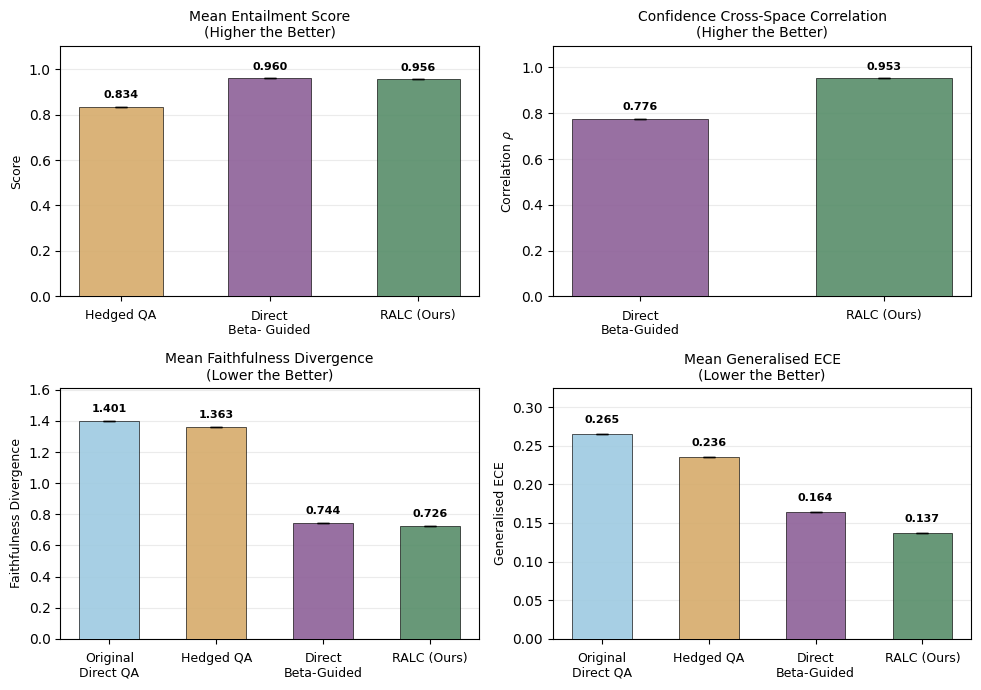

In [31]:
import matplotlib.pyplot as plt

# Values taken from the summary above
# entailment_scores = {
#     "Hedged\nQA": np.mean(direct_vs_hedged_entailment_scores),
#     "Direct\nBeta-\nGuided": np.mean(mean_entailment_by_variant["calibrated_lc_beta_guided"].tolist() + mean_entailment_by_variant["calibrated_tp_beta_guided"].tolist() + mean_entailment_by_variant["calibrated_su_beta_guided"].tolist()),
#     "RALC\n(Ours)": np.mean(mean_entailment_by_variant["calibrated_lc_rewritten"].tolist() + mean_entailment_by_variant["calibrated_tp_rewritten"].tolist() + mean_entailment_by_variant["calibrated_su_rewritten"].tolist()),
# }

entailment_scores = {
    "Hedged QA": 0.834,
    "Direct\nBeta- Guided": 0.96,
    "RALC (Ours)": 0.956,
}

confidence_propagation_correlation = {
    "Direct\nBeta-Guided": (0.761 + 0.737 + 0.829) / 3,
    "RALC (Ours)": (0.945 + 0.951 + 0.963) / 3,
}

faithfulness_divergence = {
    "Original\nDirect QA": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"],
    "Hedged QA": hedged_qa_metrics["faithfulness_divergence"],
    "Direct\nBeta-Guided": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean(),
    "RALC (Ours)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean(),
}

generalised_ece = {
    "Original\nDirect QA": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"],
    "Hedged QA": hedged_qa_metrics["generalised_ECE"],
    "Direct\nBeta-Guided": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean(),
    "RALC (Ours)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean(),
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
)

def annotate_bars(ax, bars, decimals=3):
    heights = [bar.get_height() for bar in bars]
    y_max = max(heights) if heights else 0
    y_offset = max(y_max * 0.03, 0.012)

    current_bottom, current_top = ax.get_ylim()
    target_top = y_max + y_offset * 5.0
    if target_top > current_top:
        ax.set_ylim(current_bottom, target_top)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            f"{h:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            clip_on=True,
        )

# 1) Mean entailment score — 3 bars
bars0 = axes[0, 0].bar(
    list(entailment_scores.keys()),
    list(entailment_scores.values()),
    color=["#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.56,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[0, 0].set_title("Mean Entailment Score\n(Higher the Better)", fontsize=10)
axes[0, 0].set_ylabel("Score", fontsize=9)
axes[0, 0].grid(axis="y", alpha=0.25, zorder=0)
axes[0, 0].tick_params(axis="x", labelsize=9, pad=6)
annotate_bars(axes[0, 0], bars0, decimals=3)

# 2) Confidence propagation correlation — 2 bars
bars1 = axes[0, 1].bar(
    list(confidence_propagation_correlation.keys()),
    list(confidence_propagation_correlation.values()),
    color=["#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.56,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0],
)
axes[0, 1].set_title("Confidence Cross-Space Correlation\n(Higher the Better)", fontsize=10)
axes[0, 1].set_ylabel("Correlation $\\rho$", fontsize=9)
axes[0, 1].grid(axis="y", alpha=0.25, zorder=0)
axes[0, 1].tick_params(axis="x", labelsize=9, pad=6)
annotate_bars(axes[0, 1], bars1, decimals=3)

# 3) Mean faithfulness divergence — 4 bars
bars2 = axes[1, 0].bar(
    list(faithfulness_divergence.keys()),
    list(faithfulness_divergence.values()),
    color=["#9ECAE1", "#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.56,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0, 0.0],
)
axes[1, 0].set_title("Mean Faithfulness Divergence\n(Lower the Better)", fontsize=10)
axes[1, 0].set_ylabel("Faithfulness Divergence", fontsize=9)
axes[1, 0].grid(axis="y", alpha=0.25, zorder=0)
axes[1, 0].tick_params(axis="x", labelsize=9, pad=6)
annotate_bars(axes[1, 0], bars2, decimals=3)

# 4) Mean generalised ECE — 4 bars
bars3 = axes[1, 1].bar(
    list(generalised_ece.keys()),
    list(generalised_ece.values()),
    color=["#9ECAE1", "#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.56,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0, 0.0],
)
axes[1, 1].set_title("Mean Generalised ECE\n(Lower the Better)", fontsize=10)
axes[1, 1].set_ylabel("Generalised ECE", fontsize=9)
axes[1, 1].grid(axis="y", alpha=0.25, zorder=0)
axes[1, 1].tick_params(axis="x", labelsize=9, pad=6)
annotate_bars(axes[1, 1], bars3, decimals=3)

for ax in axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

fig.tight_layout()
plt.savefig("figs/calibration_performance_baselines_comparison.pdf", dpi=300, bbox_inches="tight")